In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('unet_performance_statistics_16.csv')

In [3]:
fold_to_new_mean_dice = {
    'FD-032': 0.5708,
    'FD-030': 0.8089,
    'FD-027': 0.7421,
    'FD-029': 0.7556,
    'FD-031': 0.8529,
}

In [4]:
import numpy as np
from scipy.stats import norm

In [5]:
z = norm.ppf((1 - 0.95) / 2 + 0.95)  

In [6]:
df['final_dice_coefficient'].mean()

np.float64(0.6670159366157137)

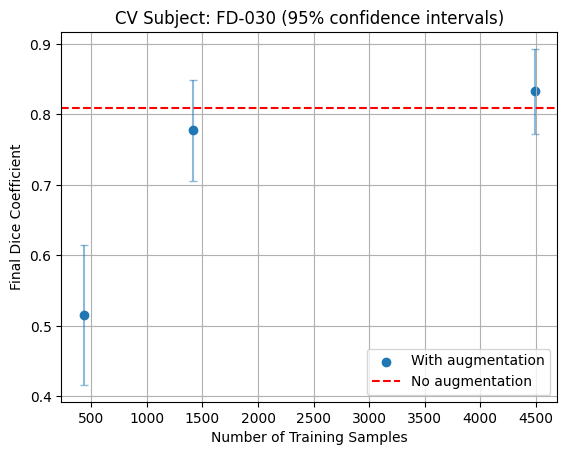

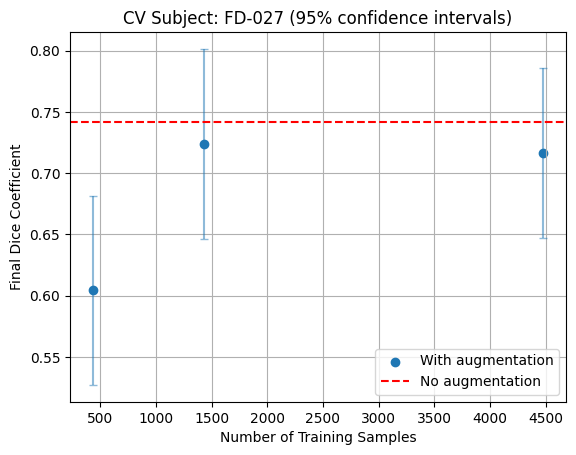

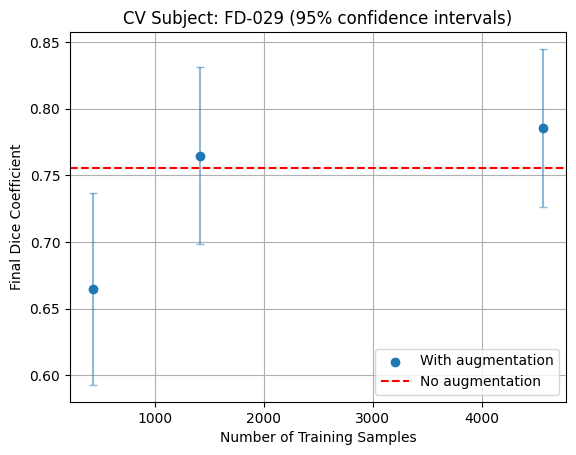

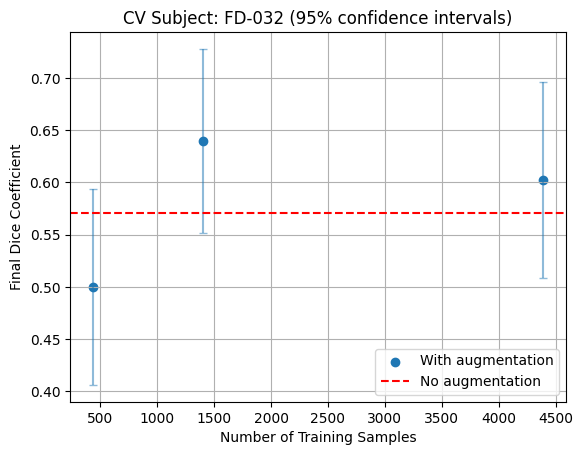

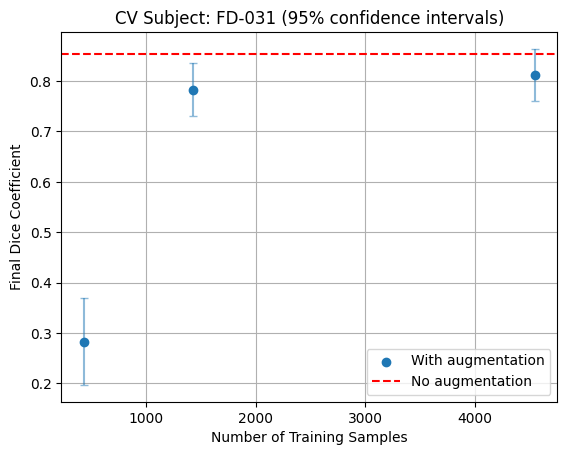

In [ ]:
cv_improvement = []


for cv_subject in df['cv_subject'].unique():
    subject_df = df[df['cv_subject'] == cv_subject]


    se = subject_df['final_dice_coefficient_std'].values / np.sqrt(subject_df['num_val_samples'].values)
    margin = z * se
    plt.scatter(subject_df['num_train_samples'].values, subject_df['final_dice_coefficient'].values, label="With augmentation")

    # add vertical error‐bars
    plt.errorbar(
        subject_df['num_train_samples'].values, 
        subject_df['final_dice_coefficient'].values,
        yerr=margin,
        fmt='none',
        ecolor='C0',
        alpha=0.5,
        capsize=3
    )


    plt.axhline(y=fold_to_new_mean_dice[cv_subject], color='r', linestyle='--', label='No augmentation')
    plt.xlabel('Number of Training Samples')
    plt.ylabel('Final Dice Coefficient')
    plt.title(f'CV Subject: {cv_subject} (95% confidence intervals)')
    plt.legend()
    plt.grid(True)
    plt.show()


In [89]:
df

,best_dice_epoch,best_dice_coefficient,best_train_loss,dice_coefficients,final_dice_coefficient,final_dice_coefficient_std,final_train_loss,train_loss_history,train_dice_coefficient_history,expansion_factor,cv_subject,exp_id,num_train_samples,num_val_samples,num_train_samples_rounded_to_100
0,0,0.848437,0.003533,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.832927,0.259877,0.003533,"[0.4097716924342387, 0.16885128906017421, 0.10...","[0.06259912928821823, 0.6457587074376225, 0.79...",16,FD-030,model-FD-030-expansion-factor-16-cv-subject-FD...,4490,72,4500
1,0,0.785193,0.006199,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0040160924873...",0.716229,0.299525,0.006199,"[0.7170499503612519, 0.34842792068208966, 0.26...","[0.01728179261329321, 0.4933799261567203, 0.71...",16,FD-027,model-FD-027-expansion-factor-16-cv-subject-FD...,4480,72,4500
2,0,0.790960,0.003068,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.785416,0.257216,0.003068,"[0.43659354267690437, 0.18293648443990498, 0.1...","[0.05751968194994302, 0.6393409433406773, 0.72...",16,FD-029,model-FD-029-expansion-factor-16-cv-subject-FD...,4567,72,4500
3,0,0.647966,0.003391,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.602380,0.405392,0.003391,"[0.6075342570075025, 0.28335086753084054, 0.17...","[0.01729411935839443, 0.20059996392746865, 0.6...",16,FD-032,model-FD-032-expansion-factor-16-cv-subject-FD...,4394,72,4500
4,0,0.826921,0.003618,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.812064,0.224373,0.003618,"[0.4172220794065774, 0.16719571904924274, 0.10...","[0.036301947437753064, 0.5679577695811097, 0.7...",16,FD-031,model-FD-031-expansion-factor-16-cv-subject-FD...,4547,72,4500
5,0,0.801991,0.032308,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.777304,0.310390,0.032308,"[0.9744513866933321, 0.6544707165039955, 0.471...","[0.029743267768979686, 0.029709797122313635, 0...",16,FD-030,model-FD-030-expansion-factor-16-cv-subject-FD...,1419,72,1400
6,0,0.798442,0.015530,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.7391303952507542e-...",0.724017,0.334872,0.015530,"[0.5354737481650185, 0.33107371014707226, 0.23...","[0.028007786230936527, 0.06741690222878619, 0....",16,FD-027,model-FD-027-expansion-factor-16-cv-subject-FD...,1428,72,1400
7,0,0.767764,0.015000,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.78571433...",0.764833,0.287993,0.015000,"[0.5051699646761719, 0.32626333673235397, 0.22...","[0.01985473325822762, 0.02355488341843624, 0.1...",16,FD-029,model-FD-029-expansion-factor-16-cv-subject-FD...,1420,72,1400
8,0,0.704819,0.008610,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.639649,0.381234,0.008610,"[0.26053964532779206, 0.17222228599612824, 0.1...","[0.02092109768925036, 0.18784575652439717, 0.5...",16,FD-032,model-FD-032-expansion-factor-16-cv-subject-FD...,1405,72,1400
9,0,0.783239,0.040145,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.783239,0.229792,0.040145,"[0.9010177672450814, 0.566929534608713, 0.3974...","[0.027199376154078383, 0.02753345501073226, 0....",16,FD-031,model-FD-031-expansion-factor-16-cv-subject-FD...,1431,72,1400


In [14]:
df['num_train_samples_rounded_to_100'] = df['num_train_samples'].apply(lambda x: round(x, -2))

In [ ]:
df.loc[df[df['num_train_samples_rounded_to_100'] == 4400].index, 'num_train_samples_rounded_to_100'] = 4500
df.loc[df[df['num_train_samples_rounded_to_100'] == 4600].index, 'num_train_samples_rounded_to_100'] = 4500

In [21]:
import ast

In [41]:
df

,best_dice_epoch,best_dice_coefficient,best_train_loss,dice_coefficients,final_dice_coefficient,final_dice_coefficient_std,final_train_loss,train_loss_history,train_dice_coefficient_history,expansion_factor,cv_subject,exp_id,num_train_samples,num_val_samples,num_train_samples_rounded_to_100
0,0,0.848437,0.003533,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.832927,0.259877,0.003533,"[0.4097716924342387, 0.16885128906017421, 0.10...","[0.06259912928821823, 0.6457587074376225, 0.79...",16,FD-030,model-FD-030-expansion-factor-16-cv-subject-FD...,4490,72,4500
1,0,0.785193,0.006199,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0040160924873...",0.716229,0.299525,0.006199,"[0.7170499503612519, 0.34842792068208966, 0.26...","[0.01728179261329321, 0.4933799261567203, 0.71...",16,FD-027,model-FD-027-expansion-factor-16-cv-subject-FD...,4480,72,4500
2,0,0.790960,0.003068,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.785416,0.257216,0.003068,"[0.43659354267690437, 0.18293648443990498, 0.1...","[0.05751968194994302, 0.6393409433406773, 0.72...",16,FD-029,model-FD-029-expansion-factor-16-cv-subject-FD...,4567,72,4500
3,0,0.647966,0.003391,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.602380,0.405392,0.003391,"[0.6075342570075025, 0.28335086753084054, 0.17...","[0.01729411935839443, 0.20059996392746865, 0.6...",16,FD-032,model-FD-032-expansion-factor-16-cv-subject-FD...,4394,72,4500
4,0,0.826921,0.003618,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.812064,0.224373,0.003618,"[0.4172220794065774, 0.16719571904924274, 0.10...","[0.036301947437753064, 0.5679577695811097, 0.7...",16,FD-031,model-FD-031-expansion-factor-16-cv-subject-FD...,4547,72,4500
5,0,0.801991,0.032308,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.777304,0.310390,0.032308,"[0.9744513866933321, 0.6544707165039955, 0.471...","[0.029743267768979686, 0.029709797122313635, 0...",16,FD-030,model-FD-030-expansion-factor-16-cv-subject-FD...,1419,72,1400
6,0,0.798442,0.015530,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.7391303952507542e-...",0.724017,0.334872,0.015530,"[0.5354737481650185, 0.33107371014707226, 0.23...","[0.028007786230936527, 0.06741690222878619, 0....",16,FD-027,model-FD-027-expansion-factor-16-cv-subject-FD...,1428,72,1400
7,0,0.767764,0.015000,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.78571433...",0.764833,0.287993,0.015000,"[0.5051699646761719, 0.32626333673235397, 0.22...","[0.01985473325822762, 0.02355488341843624, 0.1...",16,FD-029,model-FD-029-expansion-factor-16-cv-subject-FD...,1420,72,1400
8,0,0.704819,0.008610,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.639649,0.381234,0.008610,"[0.26053964532779206, 0.17222228599612824, 0.1...","[0.02092109768925036, 0.18784575652439717, 0.5...",16,FD-032,model-FD-032-expansion-factor-16-cv-subject-FD...,1405,72,1400
9,0,0.783239,0.040145,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.783239,0.229792,0.040145,"[0.9010177672450814, 0.566929534608713, 0.3974...","[0.027199376154078383, 0.02753345501073226, 0....",16,FD-031,model-FD-031-expansion-factor-16-cv-subject-FD...,1431,72,1400


In [84]:
best_performance_dice_coefficient = df[df['num_train_samples_rounded_to_100'] == 4500][['final_dice_coefficient', 'cv_subject', 'num_val_samples', 'dice_coefficients', 'best_dice_coefficient']]

In [85]:
best_performance_dice_coefficient['dice_coefficients'] = [ast.literal_eval(x) for x in best_performance_dice_coefficient['dice_coefficients']]

In [86]:
best_performance_dice_coefficient['dice_coefficients_sd'] = best_performance_dice_coefficient['dice_coefficients'].apply(lambda x: np.std(x))

In [82]:
best_performance_dice_coefficient

,final_dice_coefficient,cv_subject,num_val_samples,dice_coefficients,dice_coefficients_sd
0,0.832927,FD-030,72,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.259877
1,0.716229,FD-027,72,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0040160924873...",0.299525
2,0.785416,FD-029,72,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.257216
3,0.602380,FD-032,72,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.405392
4,0.812064,FD-031,72,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.224373


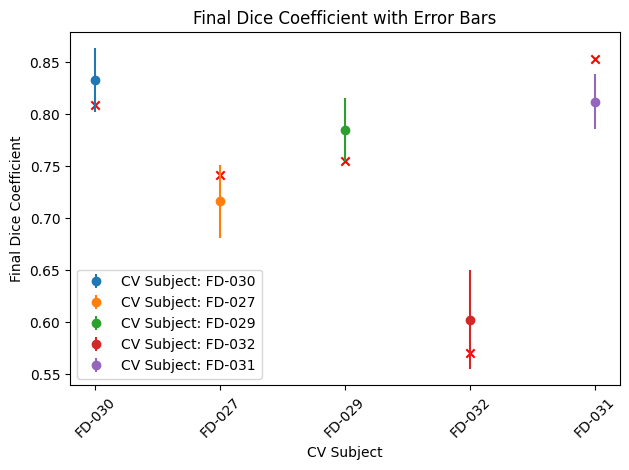

In [88]:
for i in best_performance_dice_coefficient.index:
    # Plot the error bars
    plt.errorbar(
        x=best_performance_dice_coefficient['cv_subject'][i],
        y=best_performance_dice_coefficient['final_dice_coefficient'][i],
        yerr=best_performance_dice_coefficient['dice_coefficients_sd'][i] / np.sqrt(best_performance_dice_coefficient['num_val_samples'][i]),
        fmt='o',
        label=f"CV Subject: {best_performance_dice_coefficient['cv_subject'][i]}"
    )

    # Indicate the mean Dice coefficient for the fold without augmentation
    plt.scatter(
        x=best_performance_dice_coefficient['cv_subject'][i],
        y=fold_to_new_mean_dice[best_performance_dice_coefficient['cv_subject'][i]],
        color='red',
        marker='x',
    )

    # plt.axhline(y=fold_to_new_mean_dice[best_performance_dice_coefficient['cv_subject'][i]], color='r', linestyle='--', label='No augmentation')
plt.xlabel('CV Subject')
plt.ylabel('Final Dice Coefficient')
plt.title('Final Dice Coefficient with Error Bars')

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [75]:
fold_to_new_mean_dice[best_performance_dice_coefficient['cv_subject'][i]]

0.8529

In [58]:
pd.Series(fold_to_new_mean_dice).reset_index(drop = False)

,index,0
0,FD-032,0.5708
1,FD-030,0.8089
2,FD-027,0.7421
3,FD-029,0.7556
4,FD-031,0.8529


In [55]:
df

,best_dice_epoch,best_dice_coefficient,best_train_loss,dice_coefficients,final_dice_coefficient,final_dice_coefficient_std,final_train_loss,train_loss_history,train_dice_coefficient_history,expansion_factor,cv_subject,exp_id,num_train_samples,num_val_samples,num_train_samples_rounded_to_100
0,0,0.848437,0.003533,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.832927,0.259877,0.003533,"[0.4097716924342387, 0.16885128906017421, 0.10...","[0.06259912928821823, 0.6457587074376225, 0.79...",16,FD-030,model-FD-030-expansion-factor-16-cv-subject-FD...,4490,72,4500
1,0,0.785193,0.006199,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0040160924873...",0.716229,0.299525,0.006199,"[0.7170499503612519, 0.34842792068208966, 0.26...","[0.01728179261329321, 0.4933799261567203, 0.71...",16,FD-027,model-FD-027-expansion-factor-16-cv-subject-FD...,4480,72,4500
2,0,0.790960,0.003068,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.785416,0.257216,0.003068,"[0.43659354267690437, 0.18293648443990498, 0.1...","[0.05751968194994302, 0.6393409433406773, 0.72...",16,FD-029,model-FD-029-expansion-factor-16-cv-subject-FD...,4567,72,4500
3,0,0.647966,0.003391,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.602380,0.405392,0.003391,"[0.6075342570075025, 0.28335086753084054, 0.17...","[0.01729411935839443, 0.20059996392746865, 0.6...",16,FD-032,model-FD-032-expansion-factor-16-cv-subject-FD...,4394,72,4500
4,0,0.826921,0.003618,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.812064,0.224373,0.003618,"[0.4172220794065774, 0.16719571904924274, 0.10...","[0.036301947437753064, 0.5679577695811097, 0.7...",16,FD-031,model-FD-031-expansion-factor-16-cv-subject-FD...,4547,72,4500
5,0,0.801991,0.032308,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.777304,0.310390,0.032308,"[0.9744513866933321, 0.6544707165039955, 0.471...","[0.029743267768979686, 0.029709797122313635, 0...",16,FD-030,model-FD-030-expansion-factor-16-cv-subject-FD...,1419,72,1400
6,0,0.798442,0.015530,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.7391303952507542e-...",0.724017,0.334872,0.015530,"[0.5354737481650185, 0.33107371014707226, 0.23...","[0.028007786230936527, 0.06741690222878619, 0....",16,FD-027,model-FD-027-expansion-factor-16-cv-subject-FD...,1428,72,1400
7,0,0.767764,0.015000,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.78571433...",0.764833,0.287993,0.015000,"[0.5051699646761719, 0.32626333673235397, 0.22...","[0.01985473325822762, 0.02355488341843624, 0.1...",16,FD-029,model-FD-029-expansion-factor-16-cv-subject-FD...,1420,72,1400
8,0,0.704819,0.008610,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.639649,0.381234,0.008610,"[0.26053964532779206, 0.17222228599612824, 0.1...","[0.02092109768925036, 0.18784575652439717, 0.5...",16,FD-032,model-FD-032-expansion-factor-16-cv-subject-FD...,1405,72,1400
9,0,0.783239,0.040145,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.783239,0.229792,0.040145,"[0.9010177672450814, 0.566929534608713, 0.3974...","[0.027199376154078383, 0.02753345501073226, 0....",16,FD-031,model-FD-031-expansion-factor-16-cv-subject-FD...,1431,72,1400


In [ ]:
df['']

,best_dice_epoch,best_dice_coefficient,best_train_loss,dice_coefficients,final_dice_coefficient,final_dice_coefficient_std,final_train_loss,train_loss_history,train_dice_coefficient_history,expansion_factor,cv_subject,exp_id,num_train_samples,num_val_samples,num_train_samples_rounded_to_100
0,0,0.848437,0.003533,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.832927,0.259877,0.003533,"[0.4097716924342387, 0.16885128906017421, 0.10...","[0.06259912928821823, 0.6457587074376225, 0.79...",16,FD-030,model-FD-030-expansion-factor-16-cv-subject-FD...,4490,72,4500
1,0,0.785193,0.006199,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0040160924873...",0.716229,0.299525,0.006199,"[0.7170499503612519, 0.34842792068208966, 0.26...","[0.01728179261329321, 0.4933799261567203, 0.71...",16,FD-027,model-FD-027-expansion-factor-16-cv-subject-FD...,4480,72,4500
2,0,0.790960,0.003068,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.785416,0.257216,0.003068,"[0.43659354267690437, 0.18293648443990498, 0.1...","[0.05751968194994302, 0.6393409433406773, 0.72...",16,FD-029,model-FD-029-expansion-factor-16-cv-subject-FD...,4567,72,4500
3,0,0.647966,0.003391,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.602380,0.405392,0.003391,"[0.6075342570075025, 0.28335086753084054, 0.17...","[0.01729411935839443, 0.20059996392746865, 0.6...",16,FD-032,model-FD-032-expansion-factor-16-cv-subject-FD...,4394,72,4500
4,0,0.826921,0.003618,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.812064,0.224373,0.003618,"[0.4172220794065774, 0.16719571904924274, 0.10...","[0.036301947437753064, 0.5679577695811097, 0.7...",16,FD-031,model-FD-031-expansion-factor-16-cv-subject-FD...,4547,72,4500
5,0,0.801991,0.032308,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.777304,0.310390,0.032308,"[0.9744513866933321, 0.6544707165039955, 0.471...","[0.029743267768979686, 0.029709797122313635, 0...",16,FD-030,model-FD-030-expansion-factor-16-cv-subject-FD...,1419,72,1400
6,0,0.798442,0.015530,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.7391303952507542e-...",0.724017,0.334872,0.015530,"[0.5354737481650185, 0.33107371014707226, 0.23...","[0.028007786230936527, 0.06741690222878619, 0....",16,FD-027,model-FD-027-expansion-factor-16-cv-subject-FD...,1428,72,1400
7,0,0.767764,0.015000,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.78571433...",0.764833,0.287993,0.015000,"[0.5051699646761719, 0.32626333673235397, 0.22...","[0.01985473325822762, 0.02355488341843624, 0.1...",16,FD-029,model-FD-029-expansion-factor-16-cv-subject-FD...,1420,72,1400
8,0,0.704819,0.008610,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.639649,0.381234,0.008610,"[0.26053964532779206, 0.17222228599612824, 0.1...","[0.02092109768925036, 0.18784575652439717, 0.5...",16,FD-032,model-FD-032-expansion-factor-16-cv-subject-FD...,1405,72,1400
9,0,0.783239,0.040145,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.783239,0.229792,0.040145,"[0.9010177672450814, 0.566929534608713, 0.3974...","[0.027199376154078383, 0.02753345501073226, 0....",16,FD-031,model-FD-031-expansion-factor-16-cv-subject-FD...,1431,72,1400


Coefficient mean: 0.7498032010543476
New mean average score: 0.74606
Coefficient mean: 0.7378083289844143
New mean average score: 0.74606
Coefficient mean: 0.5134362798083789
New mean average score: 0.74606


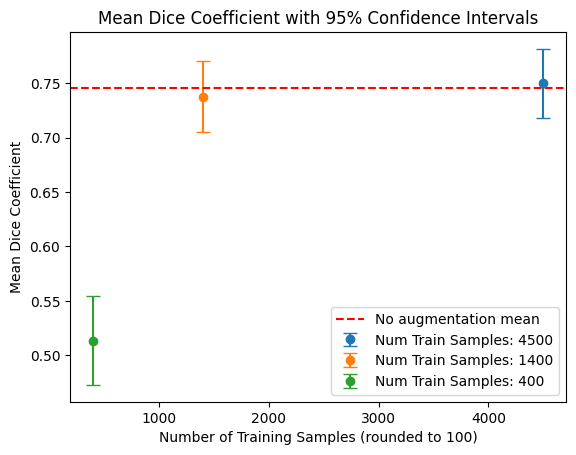

In [ ]:

for num_train_samples in df['num_train_samples_rounded_to_100'].unique():
    cv_subjects_df = df[df['num_train_samples_rounded_to_100'] == num_train_samples]
    dice_coefficients = cv_subjects_df['dice_coefficients'].values.tolist()
    # Merge the strings of arrays
    merged_dice_coefficients = [item for sublist in dice_coefficients for item in ast.literal_eval(sublist)]

    coefficient_mean = np.mean(merged_dice_coefficients)
    coefficient_std = np.std(merged_dice_coefficients)

    print('Coefficient mean:', coefficient_mean)
    print('New mean average score:', pd.Series(fold_to_new_mean_dice).mean())

    coefficient_stderr = coefficient_std / np.sqrt(len(merged_dice_coefficients))
    margin = z * coefficient_stderr

    # Plot the mean and margin
    plt.errorbar(
        num_train_samples,
        coefficient_mean,
        yerr=margin,
        fmt='o',
        label=f'Num Train Samples: {num_train_samples}',
        capsize=5
    )
plt.axhline(pd.Series(fold_to_new_mean_dice).mean(), color='r', linestyle='--', label='No augmentation mean')
plt.xlabel('Number of Training Samples (rounded to 100)')
plt.ylabel('Mean Dice Coefficient')
plt.title('Mean Dice Coefficient with 95% Confidence Intervals')
plt.legend()


In [32]:
coefficient_mean

np.float64(0.7498032010543476)

In [33]:
margin

np.float64(0.03177227278186264)

In [38]:
pd.Series(fold_to_new_mean_dice).mean()

np.float64(0.74606)

In [36]:
fold_to_new_mean_dice

{'FD-032': 0.5708,
 'FD-030': 0.8089,
 'FD-027': 0.7421,
 'FD-029': 0.7556,
 'FD-031': 0.8529}

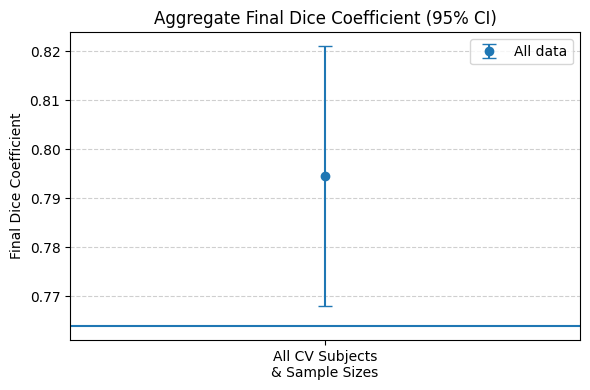

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# z‐score for 95% CI
z = 1.96

# pull out arrays
means = df['final_dice_coefficient'].values
stds  = df['final_dice_coefficient_std'].values
ns    = df['num_val_samples'].values

# per‐row variance  the mofean estimate
var_i = stds**2 / ns

# weights = 1/variance
w = 1.0 / var_i

# combined (weighted) mean
mu = np.sum(w * means) / np.sum(w)

# combined variance and SE
var_combined = 1.0 / np.sum(w)
se_combined  = np.sqrt(var_combined)
margin       = z * se_combined

# plot one point with error bar
plt.figure(figsize=(6,4))
plt.errorbar(
    1,           # x‐position (arbitrary single category)
    mu, 
    yerr=margin,
    fmt='o',
    capsize=5,
    label='All data'
)

plt.axhline(df['final_dice_coefficient'].mean())

# tidy up the axes
plt.xlim(0.5, 1.5)
plt.xticks([1], ['All CV Subjects\n& Sample Sizes'])
plt.ylabel('Final Dice Coefficient')
plt.title('Aggregate Final Dice Coefficient (95% CI)')
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


In [26]:
means

array([0.82891692, 0.72146118, 0.78969935, 0.62894299, 0.85078953])

In [27]:
stds

array([0.24377917, 0.30293277, 0.24620457, 0.3844654 , 0.19941904])

In [ ]:
# Find the mean of the whole dataset of dice coefficients
# Find the 

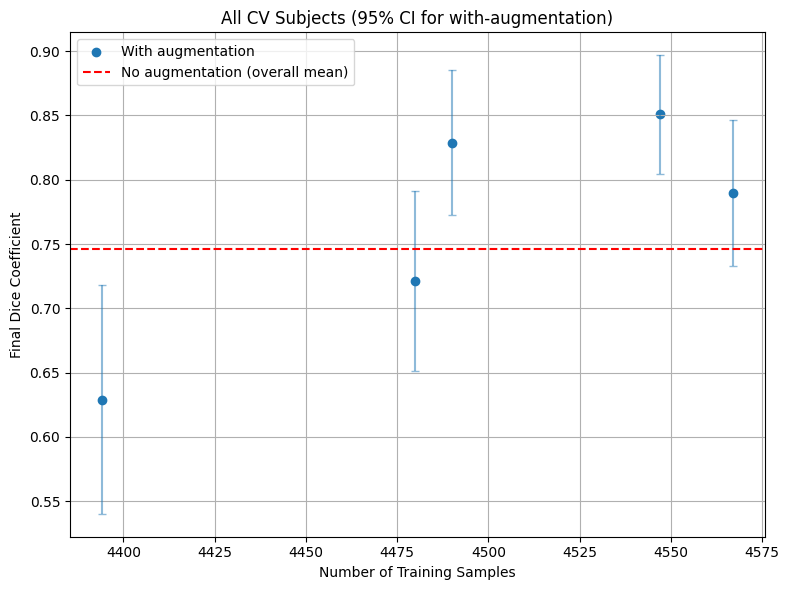

In [ ]:
cv_improvement = [
]

In [11]:
df['num_train_samples_rounded_to_100'] = df['num_train_samples'].apply(lambda x: round(x, -2))

In [12]:
cols = df['cv_subject'].unique().tolist()

In [13]:
df.loc[df[df['num_train_samples_rounded_to_100'] == 4400].index, 'num_train_samples_rounded_to_100'] = 4500
df.loc[df[df['num_train_samples_rounded_to_100'] == 4600].index, 'num_train_samples_rounded_to_100'] = 4500


In [14]:
df['num_train_samples_rounded_to_100'].unique()

array([ 900, 2500,  600,  400, 1400, 4500])

In [23]:
df

,best_dice_epoch,best_dice_coefficient,best_train_loss,final_dice_coefficient,final_train_loss,train_loss_history,train_dice_coefficient_history,expansion_factor,cv_subject,exp_id,num_train_samples,num_val_samples,num_train_samples_rounded_to_100
0,0,0.840561,0.029230,0.826475,0.029230,"[0.5518593656615236, 0.4151459375740344, 0.294...","[0.03302479892429246, 0.03521454485340145, 0.0...",16,FD-030,model-FD-030-expansion-factor-16-cv-subject-FD...,861,72,900
1,0,0.693422,0.057907,0.693422,0.057907,"[0.722922773971114, 0.5387170949647593, 0.4131...","[0.0306130534076978, 0.030472652987292407, 0.0...",16,FD-027,model-FD-027-expansion-factor-16-cv-subject-FD...,860,72,900
2,0,0.687663,0.068637,0.687663,0.068637,"[0.9139854978071796, 0.6664700844651468, 0.504...","[0.02385338470483694, 0.02375457609930539, 0.0...",16,FD-029,model-FD-029-expansion-factor-16-cv-subject-FD...,859,72,900
3,0,0.642579,0.021693,0.616923,0.021693,"[0.40873004058235335, 0.31402908398853085, 0.2...","[0.027107543617429085, 0.02733532228191757, 0....",16,FD-032,model-FD-032-expansion-factor-16-cv-subject-FD...,861,72,900
4,0,0.843888,0.031768,0.843888,0.031768,"[0.5666383372412788, 0.4295478838461417, 0.325...","[0.029071249735427736, 0.029672869545514343, 0...",16,FD-031,model-FD-031-expansion-factor-16-cv-subject-FD...,864,72,900
5,0,0.812375,0.008563,0.802025,0.008563,"[0.6833561700264741, 0.4114262819867912, 0.281...","[0.03312797493929696, 0.1261599612112339, 0.23...",16,FD-030,model-FD-030-expansion-factor-16-cv-subject-FD...,2476,72,2500
6,0,0.781310,0.007968,0.750854,0.007968,"[0.5046024322509766, 0.2635931534241594, 0.178...","[0.02504743518847734, 0.04224624591082306, 0.2...",16,FD-027,model-FD-027-expansion-factor-16-cv-subject-FD...,2486,72,2500
7,0,0.780006,0.009251,0.764418,0.009251,"[0.6763210637365561, 0.35713528035061276, 0.25...","[0.018310048677564052, 0.12196280288817508, 0....",16,FD-029,model-FD-029-expansion-factor-16-cv-subject-FD...,2491,72,2500
8,0,0.663462,0.010355,0.663462,0.010807,"[0.5659579295173862, 0.29352399332044576, 0.19...","[0.02061320743536779, 0.20742452552958637, 0.6...",16,FD-032,model-FD-032-expansion-factor-16-cv-subject-FD...,2465,72,2500
9,0,0.850234,0.007486,0.850234,0.007486,"[0.6277374745882329, 0.37500832187556804, 0.26...","[0.025630984918514437, 0.028623103830566182, 0...",16,FD-031,model-FD-031-expansion-factor-16-cv-subject-FD...,2519,72,2500


In [15]:
dataset = []
index = []
for row_count in df['num_train_samples_rounded_to_100'].unique():
    row_df = df[df['num_train_samples_rounded_to_100'] == row_count]
    curr_row = {}
    for cv_subject in cols:
        subject_df = row_df[row_df['cv_subject'] == cv_subject]
        if subject_df.empty:
            curr_row[cv_subject] = None
            continue
        final_dice = subject_df['final_dice_coefficient'].values[0]
        curr_row[cv_subject] = final_dice - fold_to_new_mean_dice[cv_subject]
    index.append(row_count)
    dataset.append(curr_row)

In [16]:
improvements = pd.DataFrame(dataset, index = index)

In [17]:
improvements = improvements.reset_index()

In [18]:
improvements = improvements.sort_values(by = 'index')

In [19]:
improvements['mean'] = improvements.drop('index', axis = 1).mean(axis = 1)

In [20]:
improvements

,index,FD-030,FD-027,FD-029,FD-032,FD-031,mean
3,400,-0.252977,-0.100251,-0.203221,-0.022144,-0.501146,-0.215948
2,600,-0.338965,-0.103397,-0.018596,-0.094040,-0.048964,-0.120792
0,900,0.017575,-0.048678,-0.067937,0.046123,-0.009012,-0.012386
4,1400,0.034732,-0.052111,-0.006422,0.024364,-0.030154,-0.005918
1,2500,-0.006875,0.008754,0.008818,0.092662,-0.002666,0.020139
5,4500,0.008088,0.042115,0.019335,0.028989,-0.028136,0.014078


In [21]:
improvements

,index,FD-030,FD-027,FD-029,FD-032,FD-031,mean
3,400,-0.252977,-0.100251,-0.203221,-0.022144,-0.501146,-0.215948
2,600,-0.338965,-0.103397,-0.018596,-0.094040,-0.048964,-0.120792
0,900,0.017575,-0.048678,-0.067937,0.046123,-0.009012,-0.012386
4,1400,0.034732,-0.052111,-0.006422,0.024364,-0.030154,-0.005918
1,2500,-0.006875,0.008754,0.008818,0.092662,-0.002666,0.020139
5,4500,0.008088,0.042115,0.019335,0.028989,-0.028136,0.014078


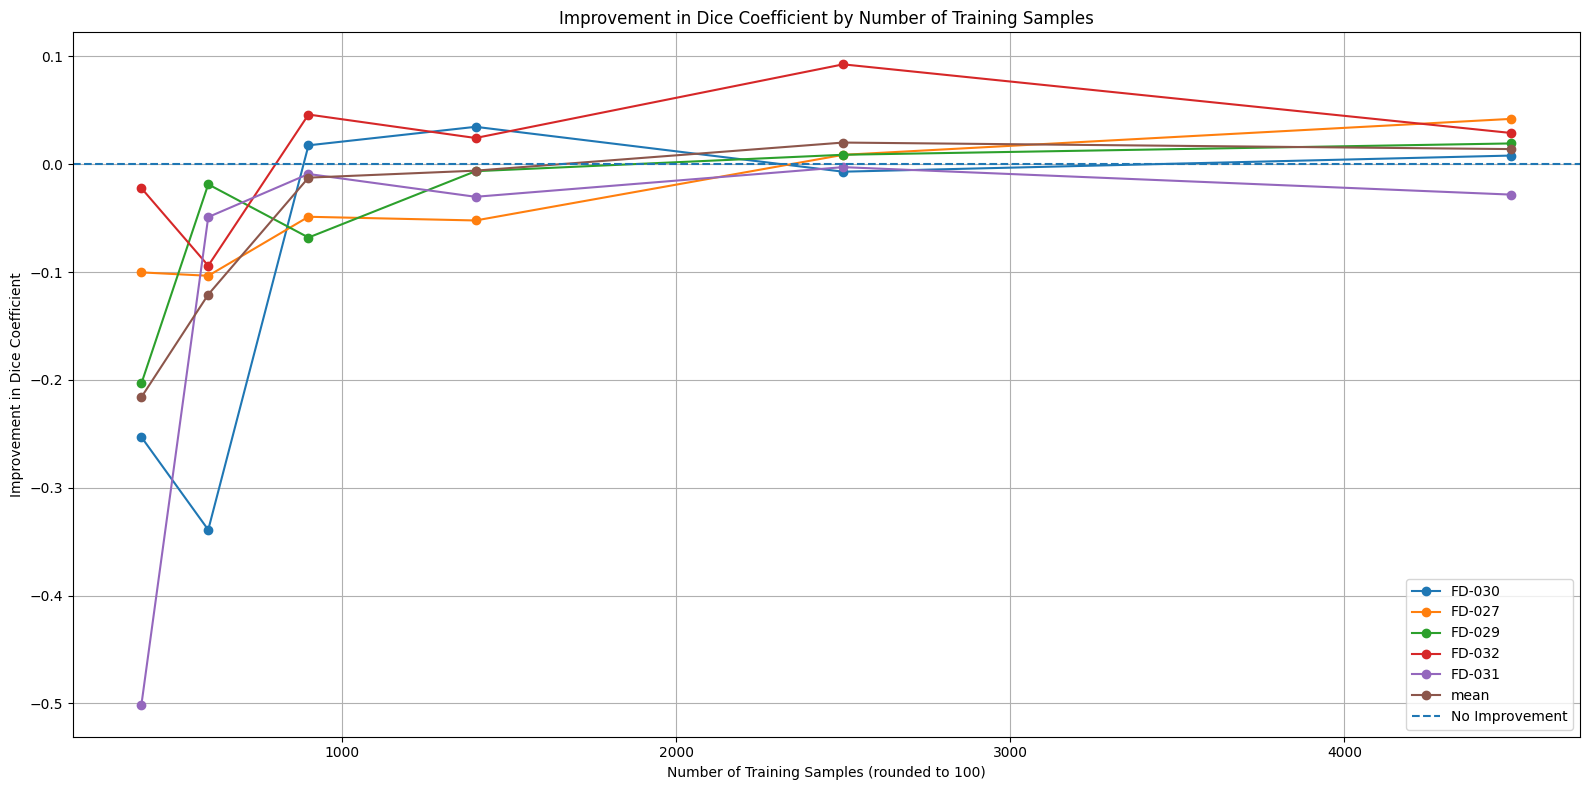

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))          # <-- bigger canvas
for cv_subject in improvements.columns[1:]:
    plt.plot(
        improvements['index'],
        improvements[cv_subject],
        marker='o',
        label=cv_subject
    )

plt.xlabel('Number of Training Samples (rounded to 100)')
plt.ylabel('Improvement in Dice Coefficient')
plt.title('Improvement in Dice Coefficient by Number of Training Samples')
plt.axhline(y=0, linestyle='--', label='No Improvement')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Plot a heatmap of the dataset

,best_dice_epoch,best_dice_coefficient,best_train_loss,final_dice_coefficient,final_train_loss,train_loss_history,train_dice_coefficient_history,expansion_factor,cv_subject,exp_id,num_train_samples,num_val_samples,num_train_samples_rounded_to_100
0,0,0.840561,0.029230,0.826475,0.029230,"[0.5518593656615236, 0.4151459375740344, 0.294...","[0.03302479892429246, 0.03521454485340145, 0.0...",16,FD-030,model-FD-030-expansion-factor-16-cv-subject-FD...,861,72,900
1,0,0.693422,0.057907,0.693422,0.057907,"[0.722922773971114, 0.5387170949647593, 0.4131...","[0.0306130534076978, 0.030472652987292407, 0.0...",16,FD-027,model-FD-027-expansion-factor-16-cv-subject-FD...,860,72,900
2,0,0.687663,0.068637,0.687663,0.068637,"[0.9139854978071796, 0.6664700844651468, 0.504...","[0.02385338470483694, 0.02375457609930539, 0.0...",16,FD-029,model-FD-029-expansion-factor-16-cv-subject-FD...,859,72,900
3,0,0.642579,0.021693,0.616923,0.021693,"[0.40873004058235335, 0.31402908398853085, 0.2...","[0.027107543617429085, 0.02733532228191757, 0....",16,FD-032,model-FD-032-expansion-factor-16-cv-subject-FD...,861,72,900
4,0,0.843888,0.031768,0.843888,0.031768,"[0.5666383372412788, 0.4295478838461417, 0.325...","[0.029071249735427736, 0.029672869545514343, 0...",16,FD-031,model-FD-031-expansion-factor-16-cv-subject-FD...,864,72,900
5,0,0.812375,0.008563,0.802025,0.008563,"[0.6833561700264741, 0.4114262819867912, 0.281...","[0.03312797493929696, 0.1261599612112339, 0.23...",16,FD-030,model-FD-030-expansion-factor-16-cv-subject-FD...,2476,72,2500
6,0,0.781310,0.007968,0.750854,0.007968,"[0.5046024322509766, 0.2635931534241594, 0.178...","[0.02504743518847734, 0.04224624591082306, 0.2...",16,FD-027,model-FD-027-expansion-factor-16-cv-subject-FD...,2486,72,2500
7,0,0.780006,0.009251,0.764418,0.009251,"[0.6763210637365561, 0.35713528035061276, 0.25...","[0.018310048677564052, 0.12196280288817508, 0....",16,FD-029,model-FD-029-expansion-factor-16-cv-subject-FD...,2491,72,2500
8,0,0.663462,0.010355,0.663462,0.010807,"[0.5659579295173862, 0.29352399332044576, 0.19...","[0.02061320743536779, 0.20742452552958637, 0.6...",16,FD-032,model-FD-032-expansion-factor-16-cv-subject-FD...,2465,72,2500
9,0,0.850234,0.007486,0.850234,0.007486,"[0.6277374745882329, 0.37500832187556804, 0.26...","[0.025630984918514437, 0.028623103830566182, 0...",16,FD-031,model-FD-031-expansion-factor-16-cv-subject-FD...,2519,72,2500


In [ ]:
subject_df

,best_dice_epoch,best_dice_coefficient,best_train_loss,final_dice_coefficient,final_train_loss,train_loss_history,train_dice_coefficient_history,expansion_factor,cv_subject,exp_id,num_train_samples,num_val_samples
0,0,0.840561,0.029230,0.826475,0.029230,"[0.5518593656615236, 0.4151459375740344, 0.294...","[0.03302479892429246, 0.03521454485340145, 0.0...",16,FD-030,model-FD-030-expansion-factor-16-cv-subject-FD...,861,72
5,0,0.812375,0.008563,0.802025,0.008563,"[0.6833561700264741, 0.4114262819867912, 0.281...","[0.03312797493929696, 0.1261599612112339, 0.23...",16,FD-030,model-FD-030-expansion-factor-16-cv-subject-FD...,2476,72
10,0,0.496653,0.139622,0.469935,0.139622,"[0.9758052362336053, 0.8060525953769684, 0.653...","[0.0361172116008459, 0.036338826208595486, 0.0...",16,FD-030,model-FD-030-expansion-factor-16-cv-subject-FD...,576,72
15,0,0.555923,0.083943,0.555923,0.083943,"[0.61868891009578, 0.5463018329055221, 0.47152...","[0.038195239322975076, 0.03828071766855214, 0....",16,FD-030,model-FD-030-expansion-factor-16-cv-subject-FD...,432,72
20,0,0.853230,0.009785,0.843632,0.009785,"[0.34141098785097956, 0.21082638408870577, 0.1...","[0.03098798862533445, 0.033133714189282, 0.079...",16,FD-030,model-FD-030-expansion-factor-16-cv-subject-FD...,1419,72
25,0,0.851211,0.003019,0.816988,0.003019,"[0.35389148189389624, 0.15332636833854668, 0.0...","[0.17618783962468232, 0.7104947026112558, 0.80...",16,FD-030,model-FD-030-expansion-factor-16-cv-subject-FD...,4490,72
